In [29]:
import numpy as np, pandas as pd
bikes = pd.read_csv("bikes.csv")
bikes.head()

,date,season,year,month,day_of_week,weekend,holiday,temp_actual,temp_feel,humidity,windspeed,weather_cat,rides
0,2011-01-01,winter,2011,Jan,Sat,True,no,57.399525,64.72625,80.5833,10.749882,categ2,654
1,2011-01-03,winter,2011,Jan,Mon,False,no,46.491663,49.04645,43.7273,16.636703,categ1,1229
2,2011-01-04,winter,2011,Jan,Tue,False,no,46.760000,51.09098,59.0435,10.739832,categ1,1454
3,2011-01-05,winter,2011,Jan,Wed,False,no,48.749427,52.63430,43.6957,12.522300,categ1,1518
4,2011-01-07,winter,2011,Jan,Fri,False,no,46.503324,50.79551,49.8696,11.304642,categ2,1362


In [30]:
bikes.dtypes

date            object
season          object
year             int64
month           object
day_of_week     object
weekend           bool
holiday         object
temp_actual    float64
temp_feel      float64
humidity       float64
windspeed      float64
weather_cat     object
rides            int64
dtype: object

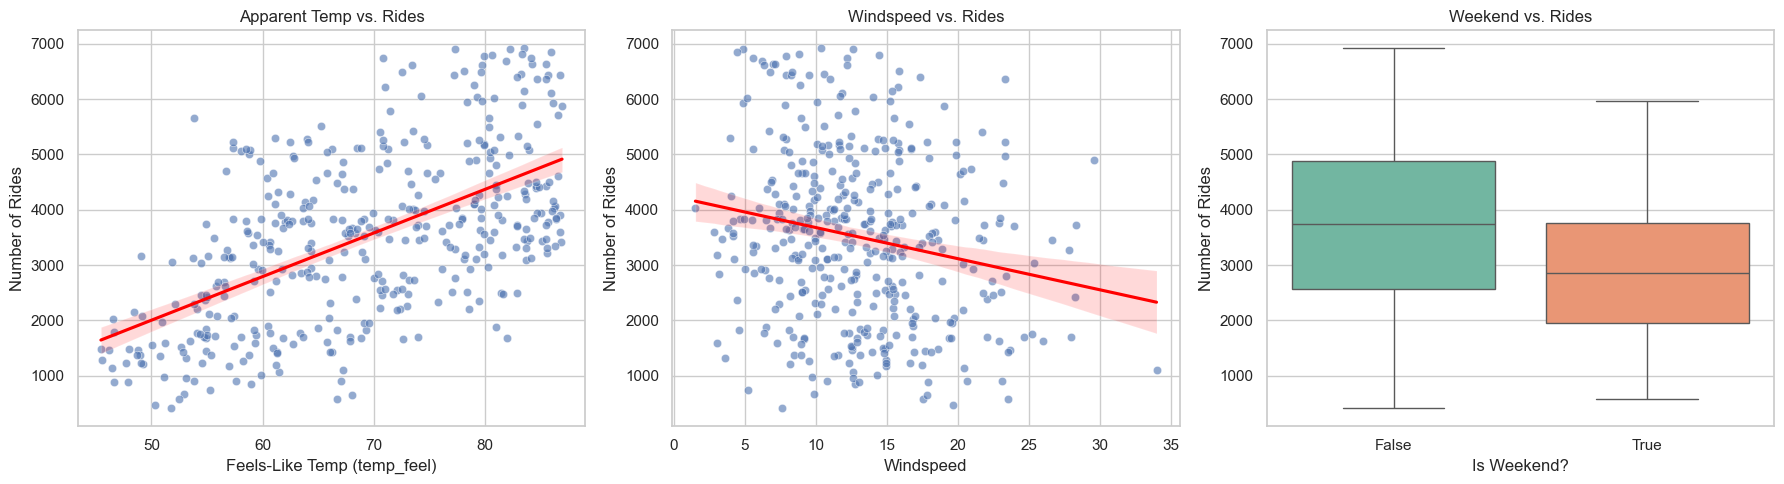

In [31]:
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. First: Split the dataset (70% Train, 30% Test)
train_df, test_df = train_test_split(bikes, test_size=0.2, random_state=42)

# Set up visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Numeric Continuous (temp_feel vs rides) ---
sns.scatterplot(
    data=train_df, x="temp_feel", y="rides", alpha=0.6, ax=axes[0]
)
sns.regplot(
    data=train_df,
    x="temp_feel",
    y="rides",
    scatter=False,
    color="red",
    ax=axes[0],
)
axes[0].set_title("Apparent Temp vs. Rides")
axes[0].set_xlabel("Feels-Like Temp (temp_feel)")
axes[0].set_ylabel("Number of Rides")

# --- Plot 2: Numeric Continuous (windspeed vs rides) ---
sns.scatterplot(
    data=train_df, x="windspeed", y="rides", alpha=0.6, ax=axes[1]
)
sns.regplot(
    data=train_df,
    x="windspeed",
    y="rides",
    scatter=False,
    color="red",
    ax=axes[1],
)
axes[1].set_title("Windspeed vs. Rides")
axes[1].set_xlabel("Windspeed")
axes[1].set_ylabel("Number of Rides")

# --- Plot 3: Binary Categorical (weekend vs rides) ---
sns.boxplot(
    data=train_df,
    x="weekend",
    y="rides",
    hue="weekend",
    palette="Set2",
    legend=False,
    ax=axes[2],
)
axes[2].set_title("Weekend vs. Rides")
axes[2].set_xlabel("Is Weekend?")
axes[2].set_ylabel("Number of Rides")

plt.tight_layout()
plt.show()


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
X = bikes[['temp_feel', 'windspeed', 'weekend']]
y = bikes['rides']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"Intercept: {model.intercept_:.4f}")
for col, coef in zip(X.columns, model.coef_):
    print(f"Coefficient ({col}): {coef:.4f}")

print(f"Train RMSE: {train_rmse:.4f} | Train R²: {train_r2:.4f}")
print(f"Test RMSE:  {test_rmse:.4f} | Test R²:  {test_r2:.4f}")

Intercept: -1110.8158
Coefficient (temp_feel): 75.0235
Coefficient (windspeed): -28.3106
Coefficient (weekend): -700.2188
Train RMSE: 1195.1987 | Train R²: 0.3908
Test RMSE:  1344.9949 | Test R²:  0.3924


In [33]:
list(zip(X, model.coef_))

[('temp_feel', np.float64(75.02352226591938)),
 ('windspeed', np.float64(-28.310575023875764)),
 ('weekend', np.float64(-700.2188026878287))]

this info was surprising to me at first.
I thought the bikes were motor bikes at first.
knowing they are manual bikes, this makes sense.
people are more likely to bike if the weather is nice (+)
less likely to bike if the wind is high (-)
less likely to bike if its the weekend (-) maybe because less people are Biking to work on the weekend

In [34]:
y_pred = model.predict(X_train)
comparison = pd.DataFrame({"Actual": y_train, "Predicted": y_pred})
print(comparison.head())

     Actual    Predicted
249    2085  2950.676295
433    6898  4924.438281
19      472  2107.290760
322    4571  3066.202283
332    3605  2945.613331


In [35]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Calculate Mean Squared Error (MSE) and take the square root for RMSE
mse_train = mean_squared_error(y_train, y_pred)
rmse_train = np.sqrt(mse_train)

# 2. Calculate R² (Coefficient of Determination)
r2_train = r2_score(y_train, y_pred)

# Display the in-sample metrics
print("--- In-Sample (Training) Performance ---")
print(f"RMSE : {rmse_train:.4f}")
print(f"R²   : {r2_train:.4f}")

--- In-Sample (Training) Performance ---
RMSE : 1195.1987
R²   : 0.3908


In [36]:
mse_test =  mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)
print(f"rmse test: {rmse_test:.4f} rmse train: {rmse_train:.4f}")
print(f"r2 test: {r2_test:.4f}, r2 train: {r2_train:.4f}")

rmse test: 1344.9949 rmse train: 1195.1987
r2 test: 0.3924, r2 train: 0.3908


this model shows good performance without using generalizations. the r2 and rmse scores are similar for both train and test sets


Part 2: logistic regression

In [37]:
ischemic = pd.read_csv("ischemic.csv")
ischemic.head

<bound method NDFrame.head of     stroke  nascet_scale    calc_vol  calc_vol_prop     matx_vol  \
0       no             0  235.252599       0.070443  3156.834690   
1       no             0   31.433595       0.016165  3032.860796   
2       no             0  113.404823       0.038081  3835.220140   
3      yes             0  780.823789       0.213432  3518.876937   
4       no             0   84.055774       0.041384  2990.273268   
..     ...           ...         ...            ...          ...   
121    yes             1  204.896563       0.085648  3564.049565   
122     no             1   79.470906       0.033084  4007.650200   
123     no             1   74.435957       0.040061  2809.318209   
124    yes             1   84.657781       0.023635  4213.809292   
125    yes             1  111.989719       0.045056  3149.167881   

     matx_vol_prop     lrnc_vol  lrnc_vol_prop  max_calc_area  \
0         0.759958   224.871710       0.091085      12.350494   
1         0.813306   36

In [38]:
ischemic.dtypes

stroke                           object
nascet_scale                      int64
calc_vol                        float64
calc_vol_prop                   float64
matx_vol                        float64
matx_vol_prop                   float64
lrnc_vol                        float64
lrnc_vol_prop                   float64
max_calc_area                   float64
max_calc_area_prop              float64
max_dilation_by_area            float64
max_matx_area                   float64
max_matx_area_prop              float64
max_lrnc_area                   float64
max_lrnc_area_prop              float64
max_max_wall_thickness          float64
max_remodeling_ratio            float64
max_stenosis_by_area            float64
max_wall_area                   float64
wall_vol                        float64
max_stenosis_by_diameter        float64
age                               int64
male                              int64
smoking_history                   int64
atrial_fibrillation               int64


"You should not have to process the data at all. Why not? In particular, what about target labels? What about the int64 variables?"
Because most of the data is one-hot, floats, or for the target, a yes/no object.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
X = ischemic.drop(columns=["stroke"])
y = ischemic["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)


In [40]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
lr = LogisticRegression(random_state=42,max_iter=1000)
lr.fit(X_train, y_train)
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)


In [41]:
train_acc = np.mean(y_train == y_pred_train)
test_acc = np.mean(y_test == y_pred_test)
print(f"Training Accuracy: {train_acc:.4f} ({train_acc * 100:.2f}%)")
print(f"Test Accuracy:     {test_acc:.4f} ({test_acc * 100:.2f}%)")

Training Accuracy: 0.7900 (79.00%)
Test Accuracy:     0.5385 (53.85%)


comments: Pretty bad to be honest!

In [43]:
train_score = lr.score(X_train, y_train)
test_score = lr.score(X_test, y_test)

print(f"Training Score: {train_score:.4f}")
print(f"Test Score:     {test_score:.4f}")

Training Score: 0.7900
Test Score:     0.5385


the default metric for "score" is mean

C's default in LogisticRegression is 1.0
C controls "regularization strength".
Regularization strength essentialy controls the influence of model coefficients. If closer to zero, coefficients will have less weight. If C is higher, then the coefficients will be able to have more influence. This can lead to overfitting if not careful.
As far as I know right now, scaling works with regularization to ensure that each model is given proportional weight. Unscaled features with high variance may give too much weight for the coefficients of features with low variance.
If a feature goes between 0-5000 and another goes between 0-4, if not scaled, the coefficient of 0-4 will be overfit.